**Objective:**

We are dealing with multiple `stationID` values occurring at the same `connectionTime` and outliers in the `KWhDelivered`, `total_charging_time`, and `idle_time` variables in this notebook. Also used Isolation Forest for Anomaly Detection.

**Input**: `df_office1_data_clean_NoUser.csv`

**Output**: `acn_office_0.2_0.1_with_stationID_22_06_2023.csv`

**Reference**:`20/03/2023 office1 stationID part-1.ipynb`

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
import os
os.chdir("/content/drive/My Drive/TL_A/DeepKale/experiments_0.2/notebook/data_processing/transfer_model/")
!ls

19062023_office_data_preprocessing_without_stationID_part_2.ipynb
19062023_office_data_preprocessing_with_stationID_part_1.ipynb


In [3]:
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline, interp1d
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.ensemble import IsolationForest

SEED = 42
np.random.seed(SEED)

In [4]:
df_office = pd.read_csv('../../../data/preprocessed/ACN/df_office1_data_clean_NoUser.csv')

In [5]:
df_office.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1621 entries, 0 to 1620
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               1621 non-null   object 
 1   clusterID         1621 non-null   int64  
 2   connectionTime    1621 non-null   object 
 3   disconnectTime    1621 non-null   object 
 4   doneChargingTime  1621 non-null   object 
 5   kWhDelivered      1621 non-null   float64
 6   sessionID         1621 non-null   object 
 7   siteID            1621 non-null   int64  
 8   spaceID           1621 non-null   int64  
 9   stationID         1621 non-null   object 
 10  futility_time     1621 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 139.4+ KB


In [6]:
df_office.shape

(1621, 11)

In [7]:
df_office.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,futility_time
0,5cd1d47af9af8b68f0e96713,102,2019-03-25 16:24:42+00:00,2019-03-26 01:32:12+00:00,2019-03-25 17:32:48+00:00,6.146,19_102_260_1633_2019-03-25 16:24:42.408146,19,2,19-102-260-1633,0 days 07:59:24
1,5cd1d47af9af8b68f0e96714,102,2019-03-25 17:19:27+00:00,2019-03-26 00:38:50+00:00,2019-03-25 18:00:49+00:00,3.658,19_102_260_1634_2019-03-25 17:19:26.896309,19,3,19-102-260-1634,0 days 06:38:01
2,5cd1d47af9af8b68f0e96715,102,2019-03-25 21:27:32+00:00,2019-03-26 03:32:03+00:00,2019-03-26 02:10:40+00:00,28.330,19_102_260_1640_2019-03-25 21:27:32.338192,19,8,19-102-260-1640,0 days 01:21:23
3,5cd1d47df9af8b68f0e96716,102,2019-03-26 18:33:56+00:00,2019-03-27 00:45:33+00:00,2019-03-26 22:30:58+00:00,12.978,19_102_260_1640_2019-03-26 18:33:56.204855,19,8,19-102-260-1640,0 days 02:14:35
4,5cd1d47ef9af8b68f0e96717,102,2019-03-27 18:28:01+00:00,2019-03-28 00:37:47+00:00,2019-03-27 21:44:03+00:00,10.688,19_102_260_1640_2019-03-27 18:28:00.642220,19,8,19-102-260-1640,0 days 02:53:44


In [8]:
# group the dataframe by spaceID and stationID columns and count the number of unique values for stationID in each group
stationID_counts = df_office.groupby(['spaceID', 'stationID'])['stationID'].nunique()

# check if there are any groups where stationID has more than one unique value
if (stationID_counts > 1).any():
    print("There are groups where stationID has different values for the same spaceID.")
else:
    print("stationID has the same value for all rows with the same spaceID.")

stationID has the same value for all rows with the same spaceID.


In [9]:
# select all rows with spaceID equal to 3
df_spaceID_3 = df_office.loc[df_office['spaceID'] == 3]

# display the selected rows
df_spaceID_3

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,futility_time
1,5cd1d47af9af8b68f0e96714,102,2019-03-25 17:19:27+00:00,2019-03-26 00:38:50+00:00,2019-03-25 18:00:49+00:00,3.658,19_102_260_1634_2019-03-25 17:19:26.896309,19,3,19-102-260-1634,0 days 06:38:01
6,5cd1d481f9af8b68f0e96719,102,2019-03-29 16:30:38+00:00,2019-03-29 20:03:10+00:00,2019-03-29 20:03:06+00:00,22.407,19_102_260_1634_2019-03-29 16:30:37.914117,19,3,19-102-260-1634,0 days 00:00:04
9,5cd1d481f9af8b68f0e9671c,102,2019-03-29 20:49:21+00:00,2019-03-30 00:56:22+00:00,2019-03-29 22:00:16+00:00,7.328,19_102_260_1634_2019-03-29 20:49:20.589006,19,3,19-102-260-1634,0 days 02:56:06
12,5cd1d486f9af8b68f0e9671f,102,2019-04-01 17:22:06+00:00,2019-04-02 00:19:14+00:00,2019-04-01 23:10:19+00:00,34.468,19_102_260_1634_2019-04-01 17:22:05.846606,19,3,19-102-260-1634,0 days 01:08:55
14,5cd1d488f9af8b68f0e96721,102,2019-04-02 20:14:39+00:00,2019-04-03 00:19:07+00:00,2019-04-02 22:43:48+00:00,15.530,19_102_260_1634_2019-04-02 20:14:39.061596,19,3,19-102-260-1634,0 days 01:35:19
...,...,...,...,...,...,...,...,...,...,...,...
1607,61492795f9af8b6473281aff,102,2021-09-01 15:40:32+00:00,2021-09-01 17:55:42+00:00,2021-09-01 17:55:33+00:00,10.219,19_102_260_1634_2021-09-01 15:40:19.616583,19,3,19-102-260-1634,0 days 00:00:09
1609,61492797f9af8b6473281b01,102,2021-09-02 15:20:11+00:00,2021-09-03 00:50:49+00:00,2021-09-03 00:50:36+00:00,39.106,19_102_260_1634_2021-09-02 15:19:59.192848,19,3,19-102-260-1634,0 days 00:00:13
1610,6149279af9af8b6473281b02,102,2021-09-03 14:26:17+00:00,2021-09-03 19:05:49+00:00,2021-09-03 19:05:17+00:00,22.032,19_102_260_1634_2021-09-03 14:26:10.027419,19,3,19-102-260-1634,0 days 00:00:32
1617,6151108ff9af8b70789b4fed,102,2021-09-10 15:33:08+00:00,2021-09-10 23:53:29+00:00,2021-09-10 22:49:37+00:00,33.186,19_102_260_1634_2021-09-10 15:32:59.042125,19,3,19-102-260-1634,0 days 01:03:52


In [10]:
# select all rows with spaceID equal to 3
df_spaceID_8 = df_office.loc[df_office['spaceID'] == 8]

# display the selected rows
df_spaceID_8

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,futility_time
2,5cd1d47af9af8b68f0e96715,102,2019-03-25 21:27:32+00:00,2019-03-26 03:32:03+00:00,2019-03-26 02:10:40+00:00,28.330,19_102_260_1640_2019-03-25 21:27:32.338192,19,8,19-102-260-1640,0 days 01:21:23
3,5cd1d47df9af8b68f0e96716,102,2019-03-26 18:33:56+00:00,2019-03-27 00:45:33+00:00,2019-03-26 22:30:58+00:00,12.978,19_102_260_1640_2019-03-26 18:33:56.204855,19,8,19-102-260-1640,0 days 02:14:35
4,5cd1d47ef9af8b68f0e96717,102,2019-03-27 18:28:01+00:00,2019-03-28 00:37:47+00:00,2019-03-27 21:44:03+00:00,10.688,19_102_260_1640_2019-03-27 18:28:00.642220,19,8,19-102-260-1640,0 days 02:53:44
8,5cd1d481f9af8b68f0e9671b,102,2019-03-29 20:21:24+00:00,2019-03-30 03:12:29+00:00,2019-03-29 23:45:47+00:00,21.026,19_102_260_1640_2019-03-29 20:21:24.158802,19,8,19-102-260-1640,0 days 03:26:42
16,5cd1d489f9af8b68f0e96723,102,2019-04-03 20:18:06+00:00,2019-04-04 04:03:02+00:00,2019-04-04 04:02:54+00:00,47.887,19_102_260_1640_2019-04-03 20:18:06.144765,19,8,19-102-260-1640,0 days 00:00:08
...,...,...,...,...,...,...,...,...,...,...,...
1611,6149279af9af8b6473281b03,102,2021-09-03 22:57:33+00:00,2021-09-04 04:10:54+00:00,2021-09-04 04:10:14+00:00,8.699,19_102_260_1640_2021-09-03 22:56:57.195425,19,8,19-102-260-1640,0 days 00:00:40
1615,614e6d8cf9af8b6c6c82bb7d,102,2021-09-08 21:05:46+00:00,2021-09-09 03:27:39+00:00,2021-09-09 03:27:12+00:00,19.053,19_102_260_1640_2021-09-08 21:05:19.174486,19,8,19-102-260-1640,0 days 00:00:27
1616,614fbf0df9af8b6e4f11442d,102,2021-09-09 21:11:44+00:00,2021-09-10 03:47:58+00:00,2021-09-10 03:47:33+00:00,19.342,19_102_260_1640_2021-09-09 21:11:26.620176,19,8,19-102-260-1640,0 days 00:00:25
1618,6151108ff9af8b70789b4fee,102,2021-09-10 21:12:26+00:00,2021-09-11 04:25:47+00:00,2021-09-11 04:25:34+00:00,19.894,19_102_260_1640_2021-09-10 21:12:15.541083,19,8,19-102-260-1640,0 days 00:00:13


In [11]:
# drop the 'spaceID' column from the df_office dataframe
df_office = df_office.drop('spaceID', axis=1)

In [12]:
df_office.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1621 entries, 0 to 1620
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               1621 non-null   object 
 1   clusterID         1621 non-null   int64  
 2   connectionTime    1621 non-null   object 
 3   disconnectTime    1621 non-null   object 
 4   doneChargingTime  1621 non-null   object 
 5   kWhDelivered      1621 non-null   float64
 6   sessionID         1621 non-null   object 
 7   siteID            1621 non-null   int64  
 8   stationID         1621 non-null   object 
 9   futility_time     1621 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 126.8+ KB


In [13]:
import pandas as pd

# get all the unique values of the 'stationID' column in the df_office dataframe
unique_station_ids = df_office['stationID'].unique()

# display the unique values
unique_station_ids

array(['19-102-260-1633', '19-102-260-1634', '19-102-260-1640',
       '19-102-260-1635', '19-102-260-1636', '19-102-260-1638',
       '19-102-260-1639', '19-102-260-1637'], dtype=object)

In [14]:
df_office.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1621 entries, 0 to 1620
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               1621 non-null   object 
 1   clusterID         1621 non-null   int64  
 2   connectionTime    1621 non-null   object 
 3   disconnectTime    1621 non-null   object 
 4   doneChargingTime  1621 non-null   object 
 5   kWhDelivered      1621 non-null   float64
 6   sessionID         1621 non-null   object 
 7   siteID            1621 non-null   int64  
 8   stationID         1621 non-null   object 
 9   futility_time     1621 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 126.8+ KB


In [15]:
# create a boolean mask of rows where stationID starts with '19-102-260'
mask = df_office['stationID'].str.startswith('19-102-260')

# display the rows where stationID starts with '19-102-260'
df_office[mask]

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5cd1d47af9af8b68f0e96713,102,2019-03-25 16:24:42+00:00,2019-03-26 01:32:12+00:00,2019-03-25 17:32:48+00:00,6.146,19_102_260_1633_2019-03-25 16:24:42.408146,19,19-102-260-1633,0 days 07:59:24
1,5cd1d47af9af8b68f0e96714,102,2019-03-25 17:19:27+00:00,2019-03-26 00:38:50+00:00,2019-03-25 18:00:49+00:00,3.658,19_102_260_1634_2019-03-25 17:19:26.896309,19,19-102-260-1634,0 days 06:38:01
2,5cd1d47af9af8b68f0e96715,102,2019-03-25 21:27:32+00:00,2019-03-26 03:32:03+00:00,2019-03-26 02:10:40+00:00,28.330,19_102_260_1640_2019-03-25 21:27:32.338192,19,19-102-260-1640,0 days 01:21:23
3,5cd1d47df9af8b68f0e96716,102,2019-03-26 18:33:56+00:00,2019-03-27 00:45:33+00:00,2019-03-26 22:30:58+00:00,12.978,19_102_260_1640_2019-03-26 18:33:56.204855,19,19-102-260-1640,0 days 02:14:35
4,5cd1d47ef9af8b68f0e96717,102,2019-03-27 18:28:01+00:00,2019-03-28 00:37:47+00:00,2019-03-27 21:44:03+00:00,10.688,19_102_260_1640_2019-03-27 18:28:00.642220,19,19-102-260-1640,0 days 02:53:44
...,...,...,...,...,...,...,...,...,...,...
1616,614fbf0df9af8b6e4f11442d,102,2021-09-09 21:11:44+00:00,2021-09-10 03:47:58+00:00,2021-09-10 03:47:33+00:00,19.342,19_102_260_1640_2021-09-09 21:11:26.620176,19,19-102-260-1640,0 days 00:00:25
1617,6151108ff9af8b70789b4fed,102,2021-09-10 15:33:08+00:00,2021-09-10 23:53:29+00:00,2021-09-10 22:49:37+00:00,33.186,19_102_260_1634_2021-09-10 15:32:59.042125,19,19-102-260-1634,0 days 01:03:52
1618,6151108ff9af8b70789b4fee,102,2021-09-10 21:12:26+00:00,2021-09-11 04:25:47+00:00,2021-09-11 04:25:34+00:00,19.894,19_102_260_1640_2021-09-10 21:12:15.541083,19,19-102-260-1640,0 days 00:00:13
1619,61550514f9af8b76948f5921,102,2021-09-13 17:35:32+00:00,2021-09-14 00:26:25+00:00,2021-09-14 00:26:05+00:00,26.688,19_102_260_1634_2021-09-13 17:35:24.605831,19,19-102-260-1634,0 days 00:00:20


In [16]:
# create a new column stationID_New by removing '9-102-260-' from stationID
df_office['stationID'] = df_office['stationID'].str.replace('19-102-260-', '')

# print the first 5 rows of the new column
df_office.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5cd1d47af9af8b68f0e96713,102,2019-03-25 16:24:42+00:00,2019-03-26 01:32:12+00:00,2019-03-25 17:32:48+00:00,6.146,19_102_260_1633_2019-03-25 16:24:42.408146,19,1633,0 days 07:59:24
1,5cd1d47af9af8b68f0e96714,102,2019-03-25 17:19:27+00:00,2019-03-26 00:38:50+00:00,2019-03-25 18:00:49+00:00,3.658,19_102_260_1634_2019-03-25 17:19:26.896309,19,1634,0 days 06:38:01
2,5cd1d47af9af8b68f0e96715,102,2019-03-25 21:27:32+00:00,2019-03-26 03:32:03+00:00,2019-03-26 02:10:40+00:00,28.330,19_102_260_1640_2019-03-25 21:27:32.338192,19,1640,0 days 01:21:23
3,5cd1d47df9af8b68f0e96716,102,2019-03-26 18:33:56+00:00,2019-03-27 00:45:33+00:00,2019-03-26 22:30:58+00:00,12.978,19_102_260_1640_2019-03-26 18:33:56.204855,19,1640,0 days 02:14:35
4,5cd1d47ef9af8b68f0e96717,102,2019-03-27 18:28:01+00:00,2019-03-28 00:37:47+00:00,2019-03-27 21:44:03+00:00,10.688,19_102_260_1640_2019-03-27 18:28:00.642220,19,1640,0 days 02:53:44


In [17]:
# remove '-' and convert to int
df_office['stationID'] = df_office['stationID'].str.replace('-', '').astype(int)

# print the first 5 rows of the new column
df_office.head()

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5cd1d47af9af8b68f0e96713,102,2019-03-25 16:24:42+00:00,2019-03-26 01:32:12+00:00,2019-03-25 17:32:48+00:00,6.146,19_102_260_1633_2019-03-25 16:24:42.408146,19,1633,0 days 07:59:24
1,5cd1d47af9af8b68f0e96714,102,2019-03-25 17:19:27+00:00,2019-03-26 00:38:50+00:00,2019-03-25 18:00:49+00:00,3.658,19_102_260_1634_2019-03-25 17:19:26.896309,19,1634,0 days 06:38:01
2,5cd1d47af9af8b68f0e96715,102,2019-03-25 21:27:32+00:00,2019-03-26 03:32:03+00:00,2019-03-26 02:10:40+00:00,28.330,19_102_260_1640_2019-03-25 21:27:32.338192,19,1640,0 days 01:21:23
3,5cd1d47df9af8b68f0e96716,102,2019-03-26 18:33:56+00:00,2019-03-27 00:45:33+00:00,2019-03-26 22:30:58+00:00,12.978,19_102_260_1640_2019-03-26 18:33:56.204855,19,1640,0 days 02:14:35
4,5cd1d47ef9af8b68f0e96717,102,2019-03-27 18:28:01+00:00,2019-03-28 00:37:47+00:00,2019-03-27 21:44:03+00:00,10.688,19_102_260_1640_2019-03-27 18:28:00.642220,19,1640,0 days 02:53:44


In [18]:
# randomly select 10 rows from df_office
random_sample = df_office.sample(n=10)

# print the randomly selected rows
random_sample

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
135,5cfda48bf9af8b26af02a738,102,2019-05-24 20:28:57+00:00,2019-05-25 01:07:35+00:00,2019-05-24 20:42:36+00:00,23.199000,19_102_260_1637_2019-05-24 20:28:57.173289,19,1637,0 days 04:24:59
843,5e2a54f2f9af8b76743d2762,102,2019-12-17 17:05:43+00:00,2019-12-18 00:06:28+00:00,2019-12-17 17:26:05+00:00,1.997000,19_102_260_1639_2019-12-17 17:05:43.505047,19,1639,0 days 06:40:23
1233,5f6e8b8ef9af8b62de292efb,102,2020-09-09 19:58:05+00:00,2020-09-11 02:22:54+00:00,2020-09-11 02:22:49+00:00,59.012000,19_102_260_1636_2020-09-09 19:58:04.969271,19,1636,0 days 00:00:05
1214,5f30950cf9af8b64b8ccabc5,102,2020-07-24 19:43:58+00:00,2020-07-24 22:43:32+00:00,2020-07-24 22:43:23+00:00,18.620000,19_102_260_1633_2020-07-24 19:43:26.783790,19,1633,0 days 00:00:09
628,5dd0a29ff9af8b29e939cd47,102,2019-10-31 14:30:12+00:00,2019-10-31 21:45:27+00:00,2019-10-31 16:28:21+00:00,5.918000,19_102_260_1633_2019-10-31 14:30:12.414611,19,1633,0 days 05:17:06
1235,5f75230cf9af8b6d4fe7a995,102,2020-09-14 16:39:44+00:00,2020-09-15 01:06:11+00:00,2020-09-15 01:05:55+00:00,32.754000,19_102_260_1639_2020-09-14 16:39:44.387339,19,1639,0 days 00:00:16
1590,6122ec2ef9af8b28bc544bc3,102,2021-08-06 21:17:13+00:00,2021-08-07 03:50:58+00:00,2021-08-07 03:36:27+00:00,8.607000,19_102_260_1640_2021-08-06 21:16:51.932054,19,1640,0 days 00:14:31
813,5e2a54d4f9af8b76743d2744,102,2019-12-11 23:11:26+00:00,2019-12-12 04:47:54+00:00,2019-12-12 04:47:42+00:00,13.086000,19_102_260_1636_2019-12-11 23:11:26.168509,19,1636,0 days 00:00:12
923,5e32319df9af8b13f06e2c38,102,2020-01-13 21:14:32+00:00,2020-01-14 05:34:52+00:00,2020-01-14 05:34:19+00:00,30.932113,19_102_260_1640_2020-01-13 21:14:31.514377,19,1640,0 days 00:00:33
271,5d671c8ff9af8b7d8b349114,102,2019-08-12 16:30:30+00:00,2019-08-13 01:48:26+00:00,2019-08-12 21:22:06+00:00,30.398000,19_102_260_1634_2019-08-12 16:30:29.576874,19,1634,0 days 04:26:20


In [19]:
df_office.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1621 entries, 0 to 1620
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   _id               1621 non-null   object 
 1   clusterID         1621 non-null   int64  
 2   connectionTime    1621 non-null   object 
 3   disconnectTime    1621 non-null   object 
 4   doneChargingTime  1621 non-null   object 
 5   kWhDelivered      1621 non-null   float64
 6   sessionID         1621 non-null   object 
 7   siteID            1621 non-null   int64  
 8   stationID         1621 non-null   int64  
 9   futility_time     1621 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 126.8+ KB


In [20]:
def timezonecorrection(dataframe):
    columns_tobe_converted = ['connectionTime', 'disconnectTime', 'doneChargingTime']

    for column in columns_tobe_converted:
        dataframe[column] = pd.to_datetime(dataframe[column], utc=False, errors='ignore')
        dataframe[column] = dataframe[column].map(lambda x: pd.to_datetime(x, format='%Y-%m-%d %H:%M:%S.%f', yearfirst=True).tz_convert('America/Los_Angeles'))
        dataframe[column] = dataframe[column].dt.strftime('%Y-%m-%d %H:%M:%S.%f')
        dataframe[column] = pd.to_datetime(dataframe[column])

    return dataframe

In [21]:
office_dataframe = df_office.copy()
office_dataframe = timezonecorrection(office_dataframe)
office_dataframe

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time
0,5cd1d47af9af8b68f0e96713,102,2019-03-25 09:24:42,2019-03-25 18:32:12,2019-03-25 10:32:48,6.146,19_102_260_1633_2019-03-25 16:24:42.408146,19,1633,0 days 07:59:24
1,5cd1d47af9af8b68f0e96714,102,2019-03-25 10:19:27,2019-03-25 17:38:50,2019-03-25 11:00:49,3.658,19_102_260_1634_2019-03-25 17:19:26.896309,19,1634,0 days 06:38:01
2,5cd1d47af9af8b68f0e96715,102,2019-03-25 14:27:32,2019-03-25 20:32:03,2019-03-25 19:10:40,28.330,19_102_260_1640_2019-03-25 21:27:32.338192,19,1640,0 days 01:21:23
3,5cd1d47df9af8b68f0e96716,102,2019-03-26 11:33:56,2019-03-26 17:45:33,2019-03-26 15:30:58,12.978,19_102_260_1640_2019-03-26 18:33:56.204855,19,1640,0 days 02:14:35
4,5cd1d47ef9af8b68f0e96717,102,2019-03-27 11:28:01,2019-03-27 17:37:47,2019-03-27 14:44:03,10.688,19_102_260_1640_2019-03-27 18:28:00.642220,19,1640,0 days 02:53:44
...,...,...,...,...,...,...,...,...,...,...
1616,614fbf0df9af8b6e4f11442d,102,2021-09-09 14:11:44,2021-09-09 20:47:58,2021-09-09 20:47:33,19.342,19_102_260_1640_2021-09-09 21:11:26.620176,19,1640,0 days 00:00:25
1617,6151108ff9af8b70789b4fed,102,2021-09-10 08:33:08,2021-09-10 16:53:29,2021-09-10 15:49:37,33.186,19_102_260_1634_2021-09-10 15:32:59.042125,19,1634,0 days 01:03:52
1618,6151108ff9af8b70789b4fee,102,2021-09-10 14:12:26,2021-09-10 21:25:47,2021-09-10 21:25:34,19.894,19_102_260_1640_2021-09-10 21:12:15.541083,19,1640,0 days 00:00:13
1619,61550514f9af8b76948f5921,102,2021-09-13 10:35:32,2021-09-13 17:26:25,2021-09-13 17:26:05,26.688,19_102_260_1634_2021-09-13 17:35:24.605831,19,1634,0 days 00:00:20


In [22]:
office_dataframe['total_charging_time'] = (office_dataframe['doneChargingTime'] - office_dataframe['connectionTime']).dt.total_seconds()
office_dataframe['idle_time'] = (office_dataframe['disconnectTime'] - office_dataframe['doneChargingTime']).dt.total_seconds()

In [23]:
office_dataframe

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time,total_charging_time,idle_time
0,5cd1d47af9af8b68f0e96713,102,2019-03-25 09:24:42,2019-03-25 18:32:12,2019-03-25 10:32:48,6.146,19_102_260_1633_2019-03-25 16:24:42.408146,19,1633,0 days 07:59:24,4086.0,28764.0
1,5cd1d47af9af8b68f0e96714,102,2019-03-25 10:19:27,2019-03-25 17:38:50,2019-03-25 11:00:49,3.658,19_102_260_1634_2019-03-25 17:19:26.896309,19,1634,0 days 06:38:01,2482.0,23881.0
2,5cd1d47af9af8b68f0e96715,102,2019-03-25 14:27:32,2019-03-25 20:32:03,2019-03-25 19:10:40,28.330,19_102_260_1640_2019-03-25 21:27:32.338192,19,1640,0 days 01:21:23,16988.0,4883.0
3,5cd1d47df9af8b68f0e96716,102,2019-03-26 11:33:56,2019-03-26 17:45:33,2019-03-26 15:30:58,12.978,19_102_260_1640_2019-03-26 18:33:56.204855,19,1640,0 days 02:14:35,14222.0,8075.0
4,5cd1d47ef9af8b68f0e96717,102,2019-03-27 11:28:01,2019-03-27 17:37:47,2019-03-27 14:44:03,10.688,19_102_260_1640_2019-03-27 18:28:00.642220,19,1640,0 days 02:53:44,11762.0,10424.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1616,614fbf0df9af8b6e4f11442d,102,2021-09-09 14:11:44,2021-09-09 20:47:58,2021-09-09 20:47:33,19.342,19_102_260_1640_2021-09-09 21:11:26.620176,19,1640,0 days 00:00:25,23749.0,25.0
1617,6151108ff9af8b70789b4fed,102,2021-09-10 08:33:08,2021-09-10 16:53:29,2021-09-10 15:49:37,33.186,19_102_260_1634_2021-09-10 15:32:59.042125,19,1634,0 days 01:03:52,26189.0,3832.0
1618,6151108ff9af8b70789b4fee,102,2021-09-10 14:12:26,2021-09-10 21:25:47,2021-09-10 21:25:34,19.894,19_102_260_1640_2021-09-10 21:12:15.541083,19,1640,0 days 00:00:13,25988.0,13.0
1619,61550514f9af8b76948f5921,102,2021-09-13 10:35:32,2021-09-13 17:26:25,2021-09-13 17:26:05,26.688,19_102_260_1634_2021-09-13 17:35:24.605831,19,1634,0 days 00:00:20,24633.0,20.0


In [24]:
office_dataframe['total_charging_time'] = office_dataframe['total_charging_time'].apply(lambda x: x / 3600)
office_dataframe['idle_time'] = office_dataframe['idle_time'].apply(lambda x: x / 3600)

In [25]:
office_dataframe

,_id,clusterID,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,stationID,futility_time,total_charging_time,idle_time
0,5cd1d47af9af8b68f0e96713,102,2019-03-25 09:24:42,2019-03-25 18:32:12,2019-03-25 10:32:48,6.146,19_102_260_1633_2019-03-25 16:24:42.408146,19,1633,0 days 07:59:24,1.135000,7.990000
1,5cd1d47af9af8b68f0e96714,102,2019-03-25 10:19:27,2019-03-25 17:38:50,2019-03-25 11:00:49,3.658,19_102_260_1634_2019-03-25 17:19:26.896309,19,1634,0 days 06:38:01,0.689444,6.633611
2,5cd1d47af9af8b68f0e96715,102,2019-03-25 14:27:32,2019-03-25 20:32:03,2019-03-25 19:10:40,28.330,19_102_260_1640_2019-03-25 21:27:32.338192,19,1640,0 days 01:21:23,4.718889,1.356389
3,5cd1d47df9af8b68f0e96716,102,2019-03-26 11:33:56,2019-03-26 17:45:33,2019-03-26 15:30:58,12.978,19_102_260_1640_2019-03-26 18:33:56.204855,19,1640,0 days 02:14:35,3.950556,2.243056
4,5cd1d47ef9af8b68f0e96717,102,2019-03-27 11:28:01,2019-03-27 17:37:47,2019-03-27 14:44:03,10.688,19_102_260_1640_2019-03-27 18:28:00.642220,19,1640,0 days 02:53:44,3.267222,2.895556
...,...,...,...,...,...,...,...,...,...,...,...,...
1616,614fbf0df9af8b6e4f11442d,102,2021-09-09 14:11:44,2021-09-09 20:47:58,2021-09-09 20:47:33,19.342,19_102_260_1640_2021-09-09 21:11:26.620176,19,1640,0 days 00:00:25,6.596944,0.006944
1617,6151108ff9af8b70789b4fed,102,2021-09-10 08:33:08,2021-09-10 16:53:29,2021-09-10 15:49:37,33.186,19_102_260_1634_2021-09-10 15:32:59.042125,19,1634,0 days 01:03:52,7.274722,1.064444
1618,6151108ff9af8b70789b4fee,102,2021-09-10 14:12:26,2021-09-10 21:25:47,2021-09-10 21:25:34,19.894,19_102_260_1640_2021-09-10 21:12:15.541083,19,1640,0 days 00:00:13,7.218889,0.003611
1619,61550514f9af8b76948f5921,102,2021-09-13 10:35:32,2021-09-13 17:26:25,2021-09-13 17:26:05,26.688,19_102_260_1634_2021-09-13 17:35:24.605831,19,1634,0 days 00:00:20,6.842500,0.005556


In [26]:
mask = office_dataframe['doneChargingTime'] >= office_dataframe['connectionTime']
office_dataframe = office_dataframe.loc[mask].reset_index(drop=True)

In [27]:
mask1 = office_dataframe[office_dataframe['doneChargingTime'] >= office_dataframe['disconnectTime']]
len(mask1)

0

In [28]:
def dropping_unnecessary_columns(dataframe):
  columns_tobe_dropped = ['clusterID', '_id', 'sessionID', 'disconnectTime', 'doneChargingTime', 'futility_time']

  for column in columns_tobe_dropped:
    dataframe.drop([column], axis=1, inplace=True)

  return dataframe

In [29]:
office_dataframe =dropping_unnecessary_columns(office_dataframe)
office_dataframe.sort_values(by='connectionTime')
office_dataframe.head()

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
0,2019-03-25 09:24:42,6.146,19,1633,1.135000,7.990000
1,2019-03-25 10:19:27,3.658,19,1634,0.689444,6.633611
2,2019-03-25 14:27:32,28.330,19,1640,4.718889,1.356389
3,2019-03-26 11:33:56,12.978,19,1640,3.950556,2.243056
4,2019-03-27 11:28:01,10.688,19,1640,3.267222,2.895556


In [30]:
office_max_energy = office_dataframe.describe()['kWhDelivered']['max']
office_min_energy = office_dataframe.describe()['kWhDelivered']['min']
office_max_charging_time = office_dataframe.describe()['total_charging_time']['max']
office_min_charging_time = office_dataframe.describe()['total_charging_time']['min']
office_max_idle_time = office_dataframe.describe()['idle_time']['max']
office_min_idle_time = office_dataframe.describe()['idle_time']['min']

# Print the maximum and minimum values
print("Office Maximum and Minimum Values:")
print("-------------------------------")
print(f"Max kWhDelivered:           {office_max_energy:.3f}")
print(f"Min kWhDelivered:           {office_min_energy:.1f}")
print(f"Max total_charging_time:    {office_max_charging_time:.6f}")
print(f"Min total_charging_time:    {office_min_charging_time:.1f}")
print(f"Max idle_time:              {office_max_idle_time:.6f}")
print(f"Min idle_time:              {office_min_idle_time:.1f}")

Office Maximum and Minimum Values:
-------------------------------
Max kWhDelivered:           65.217
Min kWhDelivered:           0.5
Max total_charging_time:    72.866111
Min total_charging_time:    0.2
Max idle_time:              35.251667
Min idle_time:              0.0


In [31]:
# Select the rows where total_charging_time is 0 but kWhDelivered is not equal to 0
condition = office_dataframe['total_charging_time'] == 0

In [32]:
# Drop the selected rows from the dataframe
office_dataframe = office_dataframe.drop(office_dataframe[condition].index)

In [33]:
office_dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1621 entries, 0 to 1620
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       1621 non-null   datetime64[ns]
 1   kWhDelivered         1621 non-null   float64       
 2   siteID               1621 non-null   int64         
 3   stationID            1621 non-null   int64         
 4   total_charging_time  1621 non-null   float64       
 5   idle_time            1621 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 76.1 KB


In [34]:
office_dataframe.describe()

,kWhDelivered,siteID,stationID,total_charging_time,idle_time
count,1621.000000,1621.0,1621.000000,1621.000000,1621.000000
mean,17.288339,19.0,1636.464528,4.301035,2.136023
std,12.023249,0.0,2.616804,4.489872,3.012699
min,0.520000,19.0,1633.000000,0.161667,0.000833
25%,6.088000,19.0,1634.000000,1.962500,0.003333
50%,14.883000,19.0,1636.000000,3.433611,0.660278
75%,25.780000,19.0,1639.000000,5.977500,3.610278
max,65.217000,19.0,1640.000000,72.866111,35.251667


In [35]:
x = office_dataframe['kWhDelivered']
percentiles = [20, 30, 40]
for p in percentiles:
    percentile = stats.percentileofscore(x, p)
    print(f"{p} kWh is in the {percentile:.2f} percentile")

20 kWh is in the 61.32 percentile
30 kWh is in the 83.22 percentile
40 kWh is in the 96.24 percentile


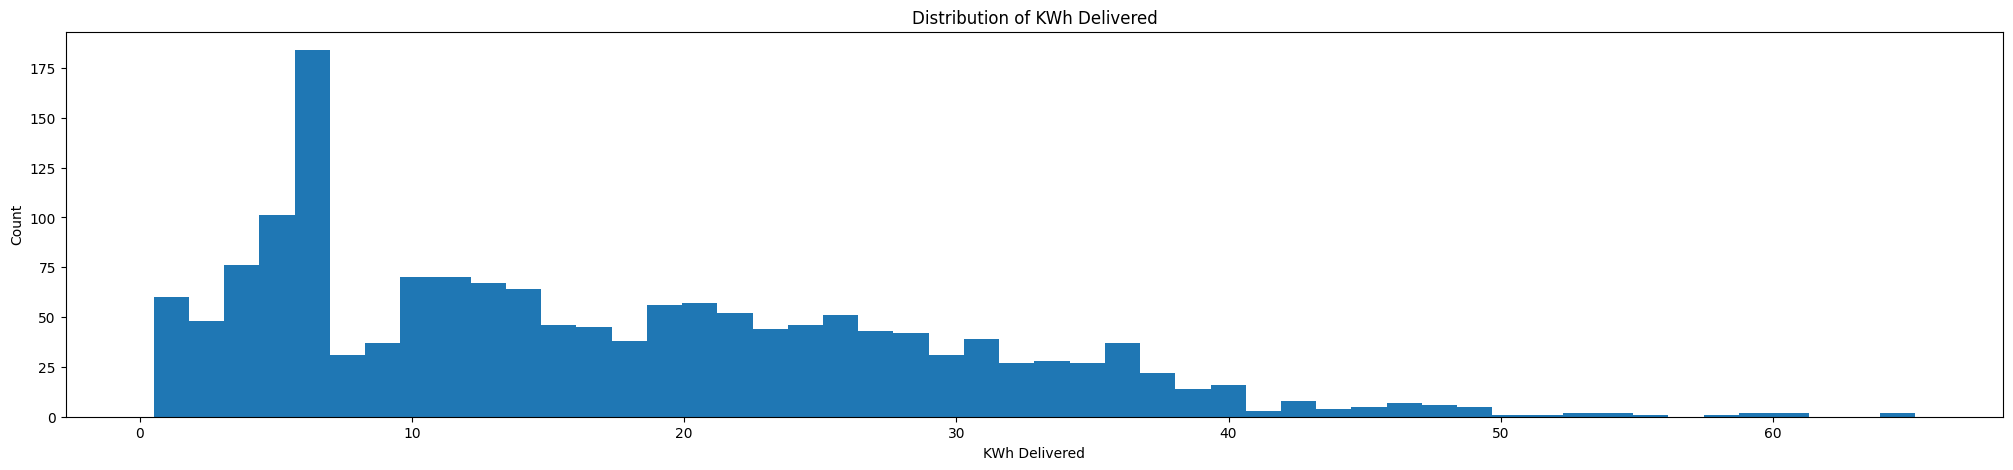

In [36]:
plt.figure(figsize=(25, 5))
plt.hist(office_dataframe['kWhDelivered'], bins=50)
plt.xlabel('KWh Delivered')
plt.ylabel('Count')
plt.title('Distribution of KWh Delivered')
plt.show()

In [37]:
fig = px.histogram(office_dataframe, x='kWhDelivered', nbins=50)
fig.update_layout(
    xaxis_title='KWh Delivered',
    yaxis_title='Count',
    title='Distribution of KWh Delivered'
)
fig.show()

In [38]:
x = office_dataframe['total_charging_time']
percentiles = [8, 9, 10]
for p in percentiles:
    percentile = stats.percentileofscore(x, p)
    print(f"{p} Hour Charging Time is in the {percentile:.2f} percentile")

8 Hour Charging Time is in the 92.10 percentile
9 Hour Charging Time is in the 96.73 percentile
10 Hour Charging Time is in the 98.70 percentile


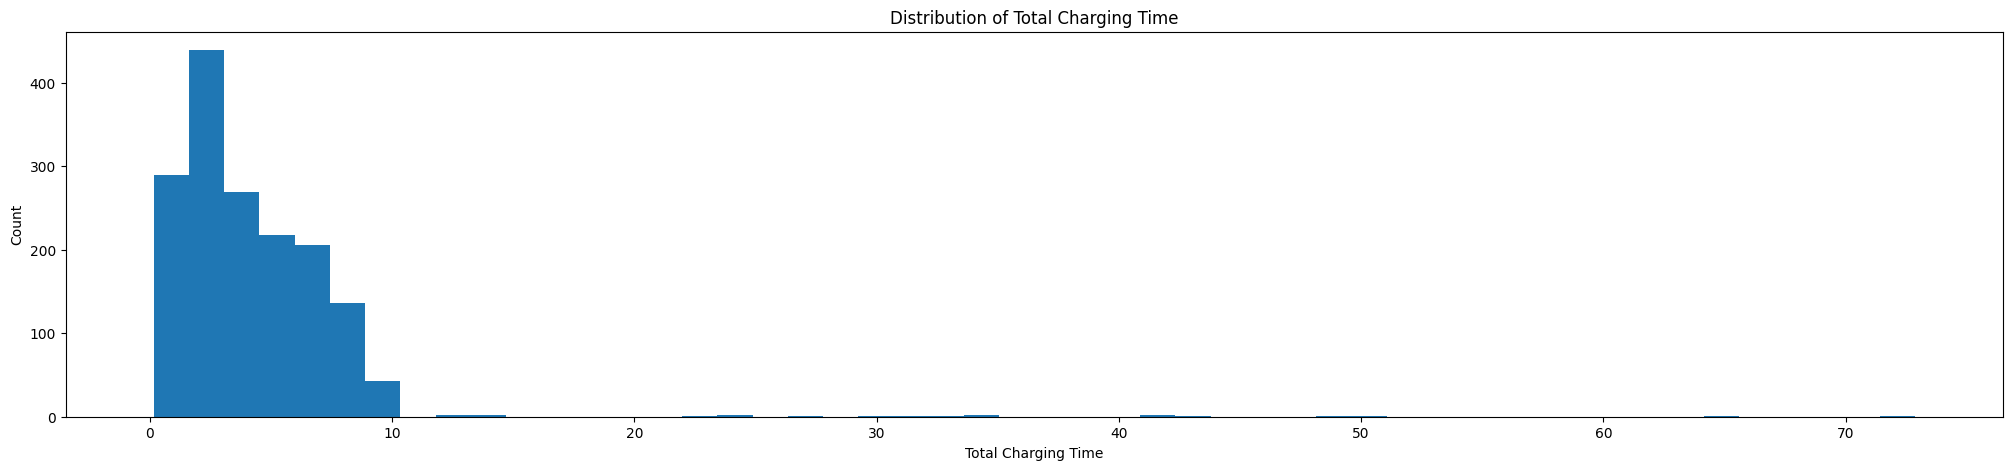

In [39]:
plt.figure(figsize=(25, 5))
plt.hist(office_dataframe['total_charging_time'], bins=50)
plt.xlabel('Total Charging Time')
plt.ylabel('Count')
plt.title('Distribution of Total Charging Time')
plt.show()

In [40]:
fig = px.histogram(office_dataframe, x='total_charging_time', nbins=50)
fig.update_layout(
    xaxis_title='Total Charging Time',
    yaxis_title='Count',
    title='Distribution of Total Charging Time'
)
fig.show()

In [41]:
x = office_dataframe['idle_time']
percentiles = [10, 11, 12, 13, 24]
for p in percentiles:
    percentile = stats.percentileofscore(x, p)
    print(f"{p} Hour Idle Time is in the {percentile:.2f} percentile")

10 Hour Idle Time is in the 99.51 percentile
11 Hour Idle Time is in the 99.63 percentile
12 Hour Idle Time is in the 99.63 percentile
13 Hour Idle Time is in the 99.63 percentile
24 Hour Idle Time is in the 99.75 percentile


In [42]:
fig = px.histogram(office_dataframe, x='idle_time', nbins=50)
fig.update_layout(
    xaxis_title='Total Idle Time',
    yaxis_title='Count',
    title='Distribution of Total Idle Time'
)
fig.show()

In [43]:
office_dataframe_before_COVID = office_dataframe.loc[office_dataframe['connectionTime'] < pd.to_datetime('2020-03-15')]
office_dataframe_before_COVID.shape

(1132, 6)

**Removing Some outliers where kWhDelivered > 40, total_charging_time > 10 and idle_time > 12**

In [44]:
office_dataframe_before_COVID = office_dataframe_before_COVID[office_dataframe_before_COVID['kWhDelivered'] <= 40].reset_index(drop=True)
office_dataframe_before_COVID = office_dataframe_before_COVID[office_dataframe_before_COVID['total_charging_time'] <= 10].reset_index(drop=True)
office_dataframe_before_COVID = office_dataframe_before_COVID[office_dataframe_before_COVID['idle_time'] <= 12].reset_index(drop=True)
office_dataframe_before_COVID

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time
0,2019-03-25 09:24:42,6.146,19,1633,1.135000,7.990000
1,2019-03-25 10:19:27,3.658,19,1634,0.689444,6.633611
2,2019-03-25 14:27:32,28.330,19,1640,4.718889,1.356389
3,2019-03-26 11:33:56,12.978,19,1640,3.950556,2.243056
4,2019-03-27 11:28:01,10.688,19,1640,3.267222,2.895556
...,...,...,...,...,...,...
1082,2020-03-13 06:53:30,19.490,19,1635,3.115278,3.406667
1083,2020-03-13 07:50:09,4.966,19,1633,1.840556,3.564444
1084,2020-03-13 11:22:10,14.311,19,1639,3.141389,3.183333
1085,2020-03-13 11:22:24,21.135,19,1640,3.719167,2.240000


In [45]:
# Find the duplicated rows based on the 'connectionTime' column
duplicated_df = office_dataframe_before_COVID[office_dataframe_before_COVID.duplicated(subset=['connectionTime'], keep=False)]

# Print the new DataFrame
duplicated_df

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time


In [46]:
office_dataframe_before_COVID.shape

(1087, 6)

In [47]:
# Drop all the duplicate rows based on the 'connectionTime' column from the original dataframe
office_dataframe_before_COVID.drop_duplicates(subset=['connectionTime'], keep=False, inplace=True)

In [48]:
office_dataframe_before_COVID.shape

(1087, 6)

In [49]:
duplicates = office_dataframe_before_COVID.duplicated(subset='connectionTime')
if duplicates.any():
    print('There are duplicates based on the connectionTime column.')
else:
    print('There are no duplicates based on the connectionTime column.')

There are no duplicates based on the connectionTime column.


In [50]:
features = ['kWhDelivered', 'total_charging_time', 'idle_time']

model = IsolationForest(n_estimators=50, max_samples='auto', contamination=0.05, verbose = False, max_features=3, random_state=SEED)
model.fit(office_dataframe_before_COVID[features].values)

IsolationForest(contamination=0.05, max_features=3, n_estimators=50,
                random_state=42, verbose=False)

In [51]:
print(model.get_params())

{'bootstrap': False, 'contamination': 0.05, 'max_features': 3, 'max_samples': 'auto', 'n_estimators': 50, 'n_jobs': None, 'random_state': 42, 'verbose': False, 'warm_start': False}


In [52]:
office_dataframe_before_COVID['scores'] = model.decision_function(office_dataframe_before_COVID[features].values)
office_dataframe_before_COVID['anomaly'] = model.predict(office_dataframe_before_COVID[features].values)

In [53]:
anomaly=office_dataframe_before_COVID.loc[office_dataframe_before_COVID['anomaly']==-1]
anomaly_index=list(anomaly.index)
anomaly

,connectionTime,kWhDelivered,siteID,stationID,total_charging_time,idle_time,scores,anomaly
48,2019-04-18 12:24:59,1.236000,19,1633,0.219722,4.518889,-0.002517,-1
100,2019-05-09 14:56:36,37.732000,19,1640,6.147222,0.048333,-0.000772,-1
113,2019-05-16 09:03:07,36.643000,19,1633,5.810278,3.044167,-0.024902,-1
128,2019-05-24 13:28:57,23.199000,19,1637,0.227500,4.416389,-0.048478,-1
153,2019-07-01 07:40:24,36.237000,19,1633,6.978056,3.289722,-0.037411,-1
168,2019-07-08 13:50:18,37.265000,19,1640,7.056944,0.084444,-0.007463,-1
178,2019-07-11 13:53:01,36.557000,19,1640,6.798611,0.289167,-0.005157,-1
200,2019-07-24 07:39:55,19.095000,19,1633,3.985556,5.588333,-0.000574,-1
216,2019-07-30 12:08:52,33.082000,19,1640,9.052500,0.002222,-0.072531,-1
272,2019-08-14 07:21:55,26.631000,19,1633,6.176944,7.837778,-0.077248,-1


In [54]:
# Drop the rows with anomalies
office_dataframe_before_COVID = office_dataframe_before_COVID.loc[office_dataframe_before_COVID['anomaly'] != -1].copy()
# Drop the "anomaly" and "score" columns
office_dataframe_before_COVID.drop(columns=["anomaly", "scores"], inplace=True)

In [55]:
office_dataframe_before_COVID.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1032 entries, 0 to 1086
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   connectionTime       1032 non-null   datetime64[ns]
 1   kWhDelivered         1032 non-null   float64       
 2   siteID               1032 non-null   int64         
 3   stationID            1032 non-null   int64         
 4   total_charging_time  1032 non-null   float64       
 5   idle_time            1032 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 56.4 KB


In [56]:
import datetime

# Define the two timestamps
start_time = datetime.datetime(2019, 3, 25, 9, 24, 42)
end_time = datetime.datetime(2020, 3, 13, 12, 8, 2)

# Compute the total number of hours between the two timestamps
total_hours = (end_time - start_time).total_seconds() // 3600

# Compute the number of samples for different time intervals
hourly_samples = int(total_hours) + 1
four_hourly_samples = int(total_hours / 4) + 1
eight_hourly_samples = int(total_hours / 8) + 1
twelve_hourly_samples = int(total_hours / 12) + 1
daily_samples = (end_time.date() - start_time.date()).days + 1

# Print the results
print(f"Hourly samples: {hourly_samples}")
print(f"4-hourly samples: {four_hourly_samples}")
print(f"8-hourly samples: {eight_hourly_samples}")
print(f"12-hourly samples: {twelve_hourly_samples}")
print(f"Daily samples: {daily_samples}")

Hourly samples: 8499
4-hourly samples: 2125
8-hourly samples: 1063
12-hourly samples: 709
Daily samples: 355


In [57]:
duplicates = office_dataframe_before_COVID.duplicated(subset='connectionTime')
if duplicates.any():
    print('There are duplicates based on the connectionTime column.')
else:
    print('There are no duplicates based on the connectionTime column.')


There are no duplicates based on the connectionTime column.


In [58]:
file_path = '../../../data/preprocessed/ACN/acn_office_0.2_0.1_with_stationID_22_06_2023.csv'
office_dataframe_before_COVID.to_csv(file_path, index=False)